## 1. Import Libraries

In [18]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")


## 2. Load Dataset

In [25]:
df = pd.read_csv("/Users/rohan/Downloads/Diabetes-prediction doem/Data/diabetes_prediction_dataset.csv")

## 3. View Dataset

In [27]:
# Shape of the dataset

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 100000
Number of columns: 9


In [28]:
# First 5 Rows 

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.00,0,1,never,25.19,6.60,140,0
1,Female,54.00,0,0,No Info,27.32,6.60,80,0
2,Male,28.00,0,0,never,27.32,5.70,158,0
3,Female,36.00,0,0,current,23.45,5.00,155,0
4,Male,76.00,1,1,current,20.14,4.80,155,0


In [29]:
# Last 5 Rows

df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.00,0,0,No Info,27.32,6.20,90,0
99996,Female,2.00,0,0,No Info,17.37,6.50,100,0
99997,Male,66.00,0,0,former,27.83,5.70,155,0
99998,Female,24.00,0,0,never,35.42,4.00,100,0
99999,Female,57.00,0,0,current,22.43,6.60,90,0


In [5]:
df.sample(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
20700,Female,58.00,0,0,never,39.73,4.8,126,0
87589,Male,58.00,0,0,former,32.83,6.1,200,0
3947,Female,52.00,0,0,never,27.32,4.5,155,0
57821,Female,68.00,0,0,never,32.09,5.0,100,0
579,Female,22.00,0,0,never,23.24,6.0,140,0
13031,Female,32.00,0,0,not current,27.32,6.1,140,0
27046,Female,0.48,0,0,No Info,14.46,6.1,100,0
94070,Female,23.00,0,0,never,21.25,6.6,145,0
82242,Male,41.00,0,0,never,27.32,6.0,100,0
69227,Male,18.00,0,0,No Info,19.79,6.5,159,0


In [30]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 8.0 MB


In [33]:
## Statistical Description

df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,41.89,0.07,0.04,27.32,5.53,138.06,0.09
std,22.52,0.26,0.19,6.64,1.07,40.71,0.28
min,0.08,0.00,0.00,10.01,3.50,80.00,0.00
25%,24.00,0.00,0.00,23.63,4.80,100.00,0.00
50%,43.00,0.00,0.00,27.32,5.80,140.00,0.00
75%,60.00,0.00,0.00,29.58,6.20,159.00,0.00
max,80.00,1.00,1.00,95.69,9.00,300.00,1.00


In [34]:
# Column Names
print("Columns:")
for column in df.columns:
    print("-", column)

Columns:
- gender
- age
- hypertension
- heart_disease
- smoking_history
- bmi
- HbA1c_level
- blood_glucose_level
- diabetes


In [36]:
# Unique Values
for column in df.columns:
    print("\n" + "-" * 50)
    print("Column:", column)
    print("Number of unique values:", df[column].nunique())
    print("Unique values:")
    print(df[column].unique()[:20])


--------------------------------------------------
Column: gender
Number of unique values: 3
Unique values:
<ArrowStringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

--------------------------------------------------
Column: age
Number of unique values: 102
Unique values:
[80. 54. 28. 36. 76. 20. 44. 79. 42. 32. 53. 78. 67. 15. 37. 40.  5. 69.
 72.  4.]

--------------------------------------------------
Column: hypertension
Number of unique values: 2
Unique values:
[0 1]

--------------------------------------------------
Column: heart_disease
Number of unique values: 2
Unique values:
[1 0]

--------------------------------------------------
Column: smoking_history
Number of unique values: 6
Unique values:
<ArrowStringArray>
['never', 'No Info', 'current', 'former', 'ever', 'not current']
Length: 6, dtype: str

--------------------------------------------------
Column: bmi
Number of unique values: 4247
Unique values:
[25.19 27.32 23.45 20.14 19.31 23.86 33.64 54.7  36.05 

## 4. Data Cleaning

In [38]:
# Missing Values
missing_values = df.isnull().sum()
print(missing_values)

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [42]:
# Duplicate Rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 3854


In [43]:
# Remove duplicates
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (96146, 9)


In [44]:
# Data Types
df.dtypes

gender                     str
age                    float64
hypertension             int64
heart_disease            int64
smoking_history            str
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

In [51]:
# Check Categorical Values

print(df["gender"].value_counts())
print(df["smoking_history"].value_counts())

gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64
smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64


In [53]:
# Check Binary Features

print("Hypertension:")
print(df["hypertension"].value_counts())

print("\nHeart Disease:")
print(df["heart_disease"].value_counts())

print("\nDiabetes:")
print(df["diabetes"].value_counts())

Hypertension:
hypertension
0    88685
1     7461
Name: count, dtype: int64

Heart Disease:
heart_disease
0    92223
1     3923
Name: count, dtype: int64

Diabetes:
diabetes
0    87664
1     8482
Name: count, dtype: int64


In [54]:
# Check Incorrect/Impossible Values
numeric_columns = [
    "age",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

for column in numeric_columns:
    print("\n", column)
    print("Minimum:", df[column].min())
    print("Maximum:", df[column].max())


 age
Minimum: 0.08
Maximum: 80.0

 bmi
Minimum: 10.01
Maximum: 95.69

 HbA1c_level
Minimum: 3.5
Maximum: 9.0

 blood_glucose_level
Minimum: 80
Maximum: 300


## 5.Exploratory Data Analysis(EDA)

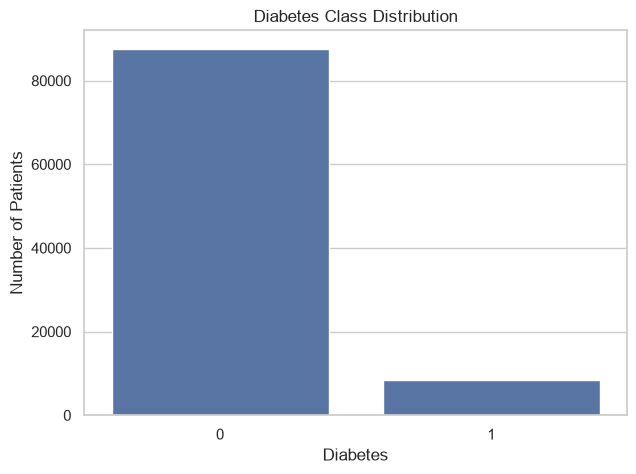

In [58]:
# Target Distribution
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="diabetes")

plt.title("Diabetes Class Distribution")
plt.xlabel("Diabetes")
plt.ylabel("Number of Patients")

plt.show()

## 6. Univariate Analysis

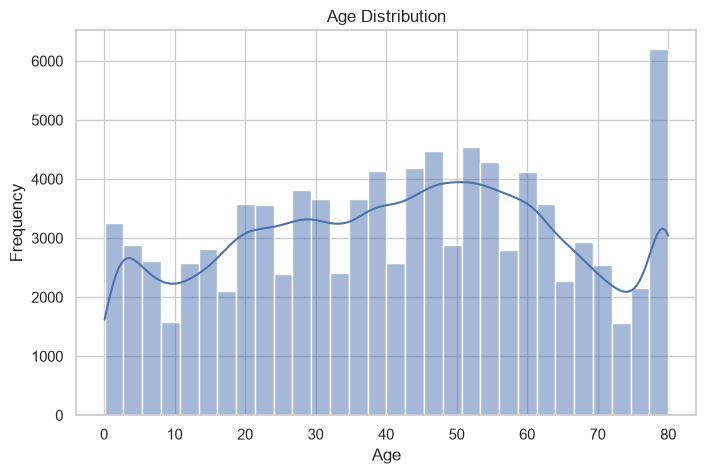

In [60]:
# Age
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="age", bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

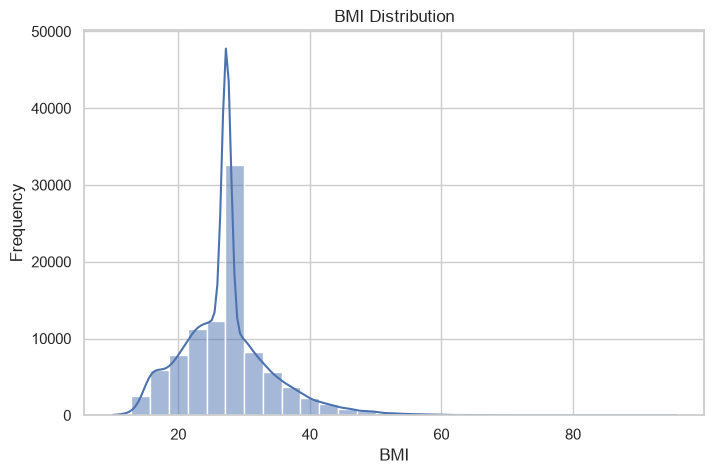

In [61]:
# BMI
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="bmi", bins=30, kde=True)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

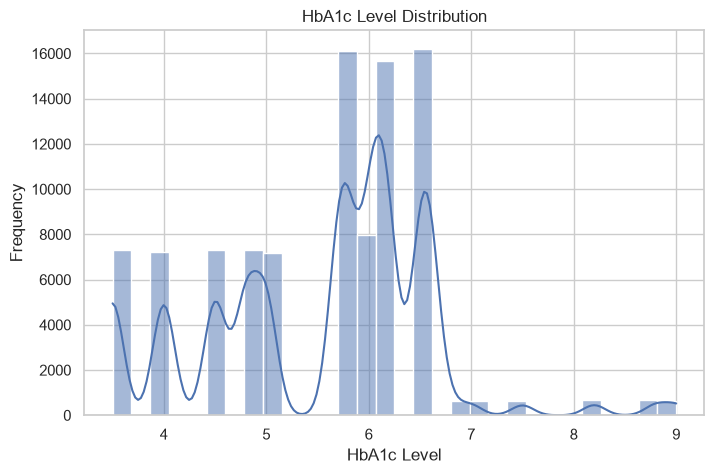

In [62]:
# HbA1c
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="HbA1c_level",
    bins=30,
    kde=True
)

plt.title("HbA1c Level Distribution")
plt.xlabel("HbA1c Level")
plt.ylabel("Frequency")

plt.show()

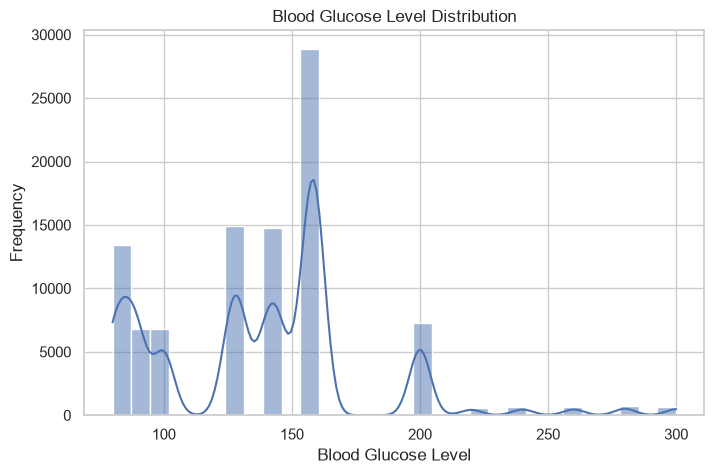

In [63]:
# Blood Glucose
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="blood_glucose_level",
    bins=30,
    kde=True
)

plt.title("Blood Glucose Level Distribution")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Frequency")

plt.show()

## 8. Correlation Analysis

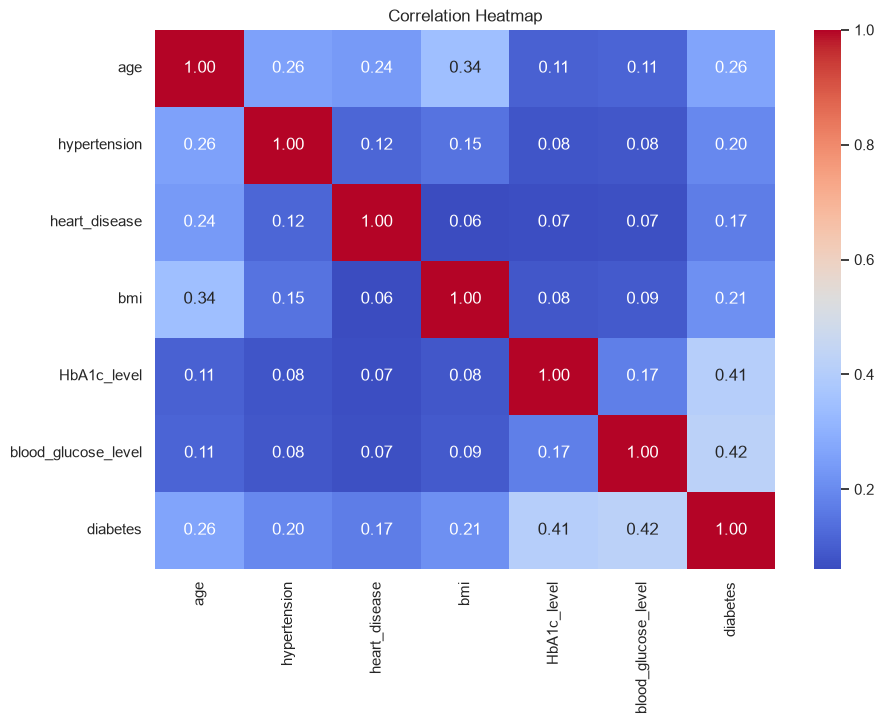

In [66]:
plt.figure(figsize=(10, 7))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [67]:
CLEANED_DATA_PATH = "data/diabetes_cleaned.csv"

df.to_csv(CLEANED_DATA_PATH, index=False)

print("Cleaned dataset saved to:")
print(CLEANED_DATA_PATH)

Cleaned dataset saved to:
data/diabetes_cleaned.csv
